In [ ]:
import os, time, glob, copy, gc

# For data manipulation
import numpy as np
import pandas as pd

# Pytorch Imports
# os.environ['KMP_DUPLICATE_LIB_OK']='True'
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Utils
from matplotlib import pyplot as plt
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
## user library 
from argments import argument
from utils import get_models, datasets, schedulers, training
from dataset import data_setup

import torch
import cv2 
from torchvision import transforms
from PIL import Image, ImageFilter,ImageDraw





In [ ]:
import timm
import torch
import torch.nn as nn

# 1. 아키텍처 정의 (가중치는 로드하지 않음)
model_name = 'vit_base_patch14_dinov2'
backbone = timm.create_model(model_name, pretrained=False)

# 2. 다운로드한 .bin 파일 경로 지정
checkpoint_path = './models/pretrained/dino_base.bin'

# 3. 가중치 로드
# 방법 A: timm 내장 함수 사용 (가장 간편함)
timm.models.load_checkpoint(backbone, checkpoint_path)

# (참고) 만약 방법 A에서 에러가 난다면, PyTorch 기본 방식인 방법 B를 사용하세요.
# state_dict = torch.load(checkpoint_path, map_location='cpu')
# backbone.load_state_dict(state_dict)

# 4. 백본 파라미터 고정 (Freeze)
for param in backbone.parameters():
    param.requires_grad = False

# 5. 분류기(Deep MLP) 정의
embed_dim = backbone.num_features # DINOv2 Base 모델은 768

classifier = nn.Sequential(
    nn.Linear(embed_dim, 1024),
    nn.BatchNorm1d(1024),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(1024, 5) # 5는 분류할 클래스 개수(num_classes)에 맞게 변경
)

# 6. 최종 모델 클래스 구성
class TransformerHeadClassifier(nn.Module):
    def __init__(self, backbone, num_classes=5, num_layers=2):
        super().__init__()
        self.backbone = backbone
        self.embed_dim = backbone.num_features # 768
        
        # 새롭게 학습할 추가 Transformer 레이어 정의
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_dim,
            nhead=8, # Multi-head Attention 개수
            dim_feedforward=2048,
            dropout=0.2,
            activation='gelu',
            batch_first=True, # 입력 형태가 (Batch, Seq, Dim) 이므로 True
            norm_first=True
        )
        self.transformer_head = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 최종 분류기
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.embed_dim),
            nn.Linear(self.embed_dim, num_classes)
        )

    def forward(self, x):
        # 백본에서 전체 토큰 가져오기
        features = self.backbone.forward_features(x)
        
        # 새 Transformer 레이어를 통과시켜 공정 도메인에 맞게 특징 재조합
        refined_features = self.transformer_head(features)
        
        # 재조합된 [CLS] 토큰(0번 인덱스) 사용
        cls_token = refined_features[:, 0, :]
        
        return self.classifier(cls_token)
    
# 모델 인스턴스화
model = TransformerHeadClassifier(backbone, num_classes=5)
model.eval()

# 정상적으로 로드되었는지 테스트 (예: 1장의 518x518 RGB 이미지)
dummy_input = torch.randn(1, 3, 518, 518)
output = model(dummy_input)
print("Output shape:", output.shape) # 기대 결과: torch.Size([1, 5])

Output shape: torch.Size([1, 5])


In [ ]:
class MultiLevelFusionClassifier(nn.Module):
    def __init__(self, backbone, num_classes=5):
        super().__init__()
        self.backbone = backbone
        self.embed_dim = backbone.num_features # 768 (Base 기준)
        
        # 4개의 레이어 특징을 연결하므로 입력 차원은 4배가 됩니다.
        fusion_dim = self.embed_dim * 4 
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 2048),
            nn.LayerNorm(2048), # Batch 크기 제약에서 자유로운 LayerNorm 사용
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(2048, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # timm의 forward_intermediates를 사용하면 지정된 중간 블록의 출력을 얻을 수 있습니다.
        # indices=[-4, -3, -2, -1] : 마지막 4개 블록
        intermediates = self.backbone.forward_intermediates(x, indices=[-4, -3, -2, -1], return_prefix_tokens=True)
        
        cls_tokens = []
        for out in intermediates:
            # 반환값 구조는 버전에 따라 다를 수 있으나, 일반적으로 
            # (patch_tokens, cls_token) 튜플 형태이거나 prefix 토큰이 포함된 텐서입니다.
            # DINOv2는 보통 sequence의 첫 번째가 CLS 토큰입니다.
            if isinstance(out, tuple):
                token = out[1][:, 0] # cls 토큰
            else:
                token = out[:, 0]
            cls_tokens.append(token)
            
        # 4개 레이어의 CLS 토큰을 하나로 연결 (Batch, 768 * 4)
        fused_features = torch.cat(cls_tokens, dim=1)
        
        return self.classifier(fused_features)

# 사용 예시
# model = MultiLevelFusionClassifier(backbone, num_classes=5)



class AttentionPoolingClassifier(nn.Module):
    def __init__(self, backbone, num_classes=5):
        super().__init__()
        self.backbone = backbone
        self.embed_dim = backbone.num_features # 768
        
        # 1. 공간적 특징 변환
        self.feature_proj = nn.Sequential(
            nn.Linear(self.embed_dim, 512),
            nn.GELU(),
            nn.LayerNorm(512)
        )
        
        # 2. Attention 가중치 계산 (패치들 중 어디가 중요한가?)
        self.attention_net = nn.Sequential(
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 1),
            nn.Softmax(dim=1) # 패치(토큰) 단위로 Softmax 적용
        )
        
        # 3. 최종 분류기
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # forward_features 출력: (Batch, Sequence_Length, 768)
        # 0번은 [CLS], 1번부터 끝까지가 패치(이미지 공간) 토큰입니다.
        features = self.backbone.forward_features(x)
        patch_tokens = features[:, 1:, :] # (Batch, N_patches, 768)
        
        # 1. 차원 축소 및 비선형 변환
        proj_tokens = self.feature_proj(patch_tokens) # (Batch, N_patches, 512)
        
        # 2. 각 패치의 중요도(Attention Score) 계산
        attn_weights = self.attention_net(proj_tokens) # (Batch, N_patches, 1)
        
        # 3. 가중 평균 (중요한 패치 위주로 정보 압축)
        # (Batch, 512, N_patches) x (Batch, N_patches, 1) -> (Batch, 512, 1)
        pooled_features = torch.bmm(proj_tokens.transpose(1, 2), attn_weights).squeeze(2)
        
        # 4. 분류
        return self.classifier(pooled_features)

tensor([[-0.4454,  0.0259,  0.2806,  0.1185,  0.3360]],
       grad_fn=<AddmmBackward0>)

In [27]:

# 중심점을 잡는 함수 
def find_center(image, ref_brightness): 

    # 그레이스케일로 변환
    # gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

    # 이진화 (thresholding)
    _, binary = cv2.threshold(image, ref_brightness, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 각 객체의 중심점 계산 및 표시
    for contour in contours:
        area = cv2.contourArea(contour)

        if area > 1000:  # 면적 임계값 (필요에 따라 조정)

            # 윤곽선의 무게중심 계산
            M = cv2.moments(contour)
            if M["m00"] != 0:  # 분모가 0이 아닌 경우에만 계산
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
    return (cX, cY)

def find_center_v1(img, canny = 30, min_R = 100, max_R = 150):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # 원 검출
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
                            param1=canny, param2=70, minRadius=min_R, maxRadius=max_R)
    
    if circles is not None:
        circles = np.uint16(np.around(circles[0]))

        # 반지름 기준으로 가장 작은 원이 안쪽 원이라고 가정
        inner_circle = min(circles, key=lambda x: x[2])
        cx, cy, r = inner_circle
        
        return (cx, cy)
    
    else:
        cX, cY = find_center(img, 45)
        return (cX, cY)
    
def get_roi(gray_blur, cx, cy, r = 560):

    # 1) PIL로 이미지 불러오기 & 그레이스케일
    pil = gray_blur
    w, h = pil.size

    # 2) PIL 마스크 만들기
    mask_pil = Image.new('L', (w, h), 0)              # 검은 배경
    draw = ImageDraw.Draw(mask_pil)
    draw.ellipse((cx-r, cy-r, cx+r, cy+r), fill=255)  # 흰색 원


    # 2’) NumPy(OpenCV) 마스크 만들기
    im_np = np.array(pil)
    mask_np = np.zeros_like(im_np, dtype=np.uint8)
    cv2.circle(mask_np, (cx, cy), r, 255, thickness=-1)

    # 3’) ROI 추출 (OpenCV bitwise)
    roi = cv2.bitwise_and(im_np, im_np, mask=mask_np)
    return roi


def get_mask(image, center, radius_in, radius_out): 
    # 마스크 생성 (검은색 배경)
    # 원형 마스크 생성
    height, width = image.shape[:2]

    mask = np.zeros((height, width), dtype=np.uint8)

    # 알파 채널 추가 (투명한 배경)
    cv2.circle(mask, center, radius_out, (255), thickness=-1)
    cv2.circle(mask, center, radius_in, (0), thickness=-1)

    # 마스크를 반전시켜서 흰색으로 만들기
    mask_inv = cv2.bitwise_not(mask)

    # 마스크를 3채널로 변환 (BGR)
    mask_3ch = cv2.merge([mask_inv, mask_inv, mask_inv])

    masked_image = cv2.bitwise_or(image, mask_3ch)

    return masked_image


In [32]:

path = r"Z:\NFF\MP2\winder\anode ftf ai"
target_path = os.path.join(path, 'donut/')
os.makedirs(target_path, exist_ok=True)

file_list = glob.glob(os.path.join(path, "*.bmp"))
print(f"Data Num: {len(file_list)}")

import tqdm 

for file_name in tqdm.tqdm(file_list):
    
    image = np.array(Image.open(file_name).convert("RGB"))

    center = find_center_v1(image, canny = 30, min_R = 90, max_R = 140)
    masked_image = get_mask(image, center, radius_in=620, radius_out=1030)
    Image.fromarray(masked_image).save(os.path.join(target_path, os.path.basename(file_name)))
    
    

Data Num: 11052


100%|██████████| 11052/11052 [1:44:41<00:00,  1.76it/s]


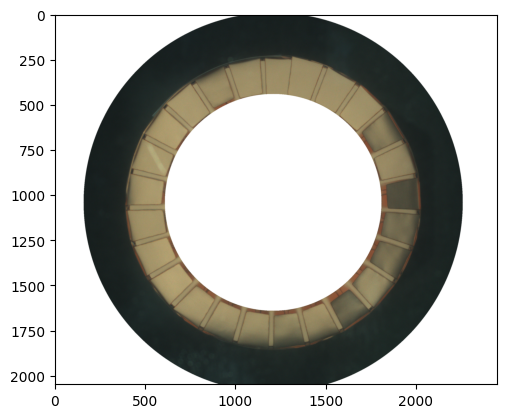

In [31]:
plt.imshow(masked_image)

In [3]:
import os, time, glob, copy, gc
import torch.nn as nn
# For data manipulation
import numpy as np

# Pytorch Imports
##os.environ['KMP_DUPLICATE_LIB_OK']='True'
import torch 

## user library 
from argments import argument
from utils import get_models, datasets, schedulers, training
from dataset import data_setup


config_path = './config/SMW_classification.yaml'

args = argument()
args.load(config_path)
DEVICE = torch.device(args.device)

## get models (configurable head: args.head_type)
model = get_models.build_model(args)
head_type = getattr(args, 'head_type', 'transformer')
print(f'**** Model head type : {head_type} ****')
print(f'**** Pretrained model : {args.pretrained} ****')

## if finetunning
    ## if finetunning .. 
if args.finetuning != False : 
    model = get_models.get_finetune_model(model, args)
    print(f'**** fine tunning model : {args.project_name}, {args.finetuning_weight} ****\n')



**** Model head type : linear ****
**** Pretrained model : tinyvit_21m_224.pth ****
**** fine tunning model : SMW_260608_WALine, f1_score0.9924_Loss0.0028340_epoch13.pth ****



In [5]:
for name, param in model.named_parameters():
    if isinstance(param, nn.Parameter):
        print(f"{name}: {param.requires_grad}")

patch_embed.conv1.conv.weight: True
patch_embed.conv1.bn.weight: True
patch_embed.conv1.bn.bias: True
patch_embed.conv2.conv.weight: True
patch_embed.conv2.bn.weight: True
patch_embed.conv2.bn.bias: True
stages.0.blocks.0.conv1.conv.weight: True
stages.0.blocks.0.conv1.bn.weight: True
stages.0.blocks.0.conv1.bn.bias: True
stages.0.blocks.0.conv2.conv.weight: True
stages.0.blocks.0.conv2.bn.weight: True
stages.0.blocks.0.conv2.bn.bias: True
stages.0.blocks.0.conv3.conv.weight: True
stages.0.blocks.0.conv3.bn.weight: True
stages.0.blocks.0.conv3.bn.bias: True
stages.0.blocks.1.conv1.conv.weight: True
stages.0.blocks.1.conv1.bn.weight: True
stages.0.blocks.1.conv1.bn.bias: True
stages.0.blocks.1.conv2.conv.weight: True
stages.0.blocks.1.conv2.bn.weight: True
stages.0.blocks.1.conv2.bn.bias: True
stages.0.blocks.1.conv3.conv.weight: True
stages.0.blocks.1.conv3.bn.weight: True
stages.0.blocks.1.conv3.bn.bias: True
stages.1.downsample.conv1.conv.weight: True
stages.1.downsample.conv1.bn.wei

In [49]:
## ONNX convert 
import torch.onnx

model.eval()
dummy_input = torch.randn((1,3,512,512), requires_grad=True).cuda()

torch.onnx.export(
    model,
    dummy_input,
    "FTF_Anode_saved_model_onnx.onnx",
    export_params = True,
    opset_version=14,
    do_constant_folding=True,
    input_names=["input"], output_names=["output"],
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}}
)


In [45]:
import pandas as pd 

path = r'C:\Users\Administrator\Desktop\AI_optimization_1\work\NFF_source\MODEL\SAVE\FTF_Anode_best\f1_score0.9992_Loss0.0019998_epoch30.pth.csv'
df = pd.read_csv(os.path.join(path))
df.loc[df["pred_label"] == 1, "file_path"].values

array(['Z:\\NFF\\MP2\\winder\\anode ftf ai\\donut\\OK\\260120_033921656_5AF16179170341_001_OK_Origin.bmp',
       'Z:\\NFF\\MP2\\winder\\anode ftf ai\\donut\\OK\\260120_190459965_5AF18126150204_001_OK_Origin.bmp',
       'Z:\\NFF\\MP2\\winder\\anode ftf ai\\donut\\OK\\260120_160349655_5AF17184150281_001_OK_Origin.bmp'],
      dtype=object)